In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/sales_data.csv.csv')

# Display the shape of the DataFrame
print(f"DataFrame Shape: {df.shape}")

DataFrame Shape: (1000, 14)


In [3]:
# Display the columns of the DataFrame
print("DataFrame Columns:")
for col in df.columns:
    print(f"- {col}")

DataFrame Columns:
- Product_ID
- Sale_Date
- Sales_Rep
- Region
- Sales_Amount
- Quantity_Sold
- Product_Category
- Unit_Cost
- Unit_Price
- Customer_Type
- Discount
- Payment_Method
- Sales_Channel
- Region_and_Sales_Rep


In [4]:
# Display data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ 

In [5]:
# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
display(df.head())


First 5 rows of the DataFrame:


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


### Data Cleaning Steps

First, I will check for missing values across all columns.

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

Missing values per column:


,0


No missing values found in the dataset.


Next, I will check for and remove any duplicate rows in the dataset.

In [7]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"{duplicate_rows} duplicate rows removed. New DataFrame shape: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 0
No duplicate rows found.


Finally, I will convert the `Sale_Date` column to a datetime object, as it was identified as an `object` type during the initial `df.info()` check.

In [8]:
# Convert 'Sale_Date' to datetime objects
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

print("Data types after converting 'Sale_Date':")
df.info()

Data types after converting 'Sale_Date':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null 

### Exploratory Data Analysis (EDA)

#### 1. Descriptive Statistics for Numerical Columns

In [9]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Product_ID,Sale_Date,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,2023-07-02 17:42:43.199999744,5019.265230,25.355000,2475.304550,2728.440120,0.15239
min,1001.000000,2023-01-01 00:00:00,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2023-03-30 00:00:00,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,2023-06-30 12:00:00,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,2023-10-12 00:00:00,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,2024-01-01 00:00:00,9989.040000,49.000000,4995.300000,5442.150000,0.30000
std,29.573505,NaN,2846.790126,14.159006,1417.872546,1419.399839,0.08720


#### 2. Analysis of Categorical Features

Let's look at the unique values and their counts for key categorical columns to understand their distribution.

In [10]:
# Analyze unique values and counts for categorical columns
categorical_cols = ['Sales_Rep', 'Region', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel']

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())
    print("-" * 30)


Value counts for 'Sales_Rep':
Sales_Rep
David      222
Eve        209
Bob        208
Alice      192
Charlie    169
Name: count, dtype: int64
------------------------------

Value counts for 'Region':
Region
North    267
East     263
West     244
South    226
Name: count, dtype: int64
------------------------------

Value counts for 'Product_Category':
Product_Category
Clothing       268
Furniture      260
Electronics    246
Food           226
Name: count, dtype: int64
------------------------------

Value counts for 'Customer_Type':
Customer_Type
New          504
Returning    496
Name: count, dtype: int64
------------------------------

Value counts for 'Payment_Method':
Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64
------------------------------

Value counts for 'Sales_Channel':
Sales_Channel
Retail    512
Online    488
Name: count, dtype: int64
------------------------------


#### 3. Sales Amount Distribution

Let's visualize the distribution of `Sales_Amount` to understand its spread and central tendency.

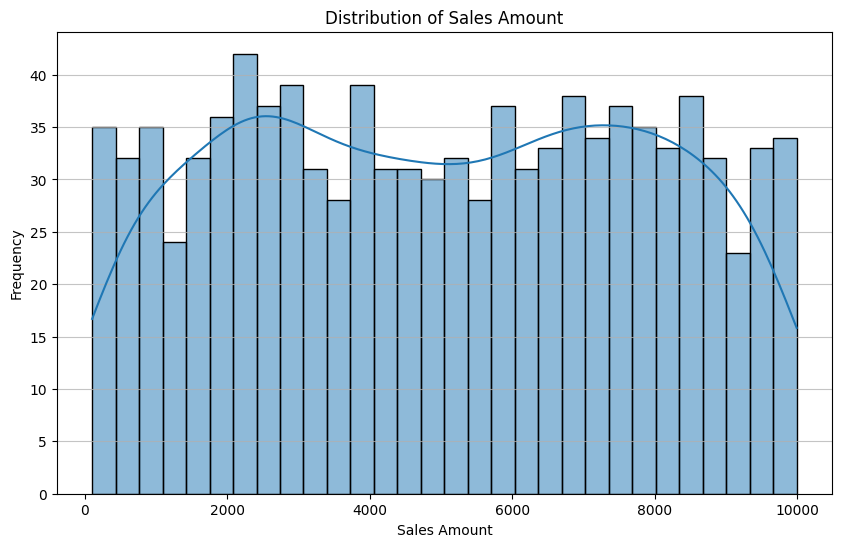

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Sales_Amount'], kde=True, bins=30)
plt.title('Distribution of Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### 4. Sales Over Time

Let's analyze the trend of sales amount over time using the `Sale_Date` column.

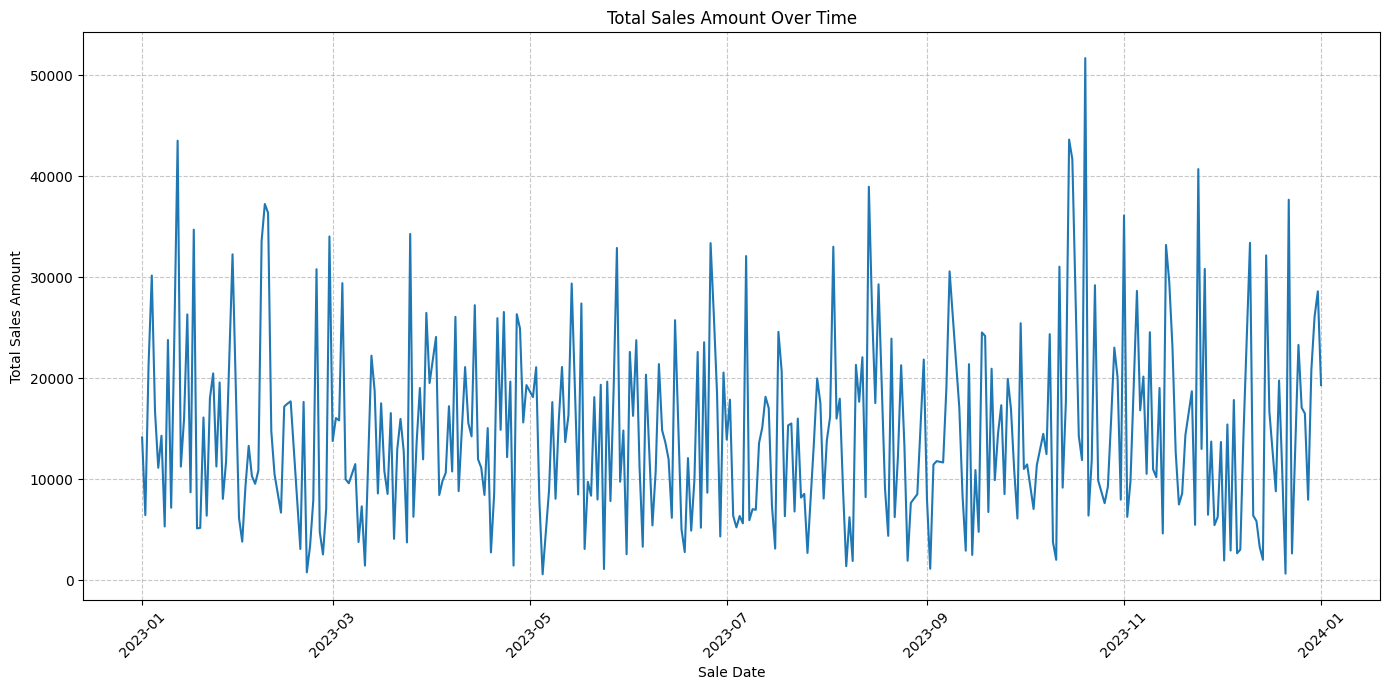

In [12]:
# Aggregate sales by date
daily_sales = df.groupby('Sale_Date')['Sales_Amount'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Sale_Date', y='Sales_Amount', data=daily_sales)
plt.title('Total Sales Amount Over Time')
plt.xlabel('Sale Date')
plt.ylabel('Total Sales Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5. Sales by Region and Product Category

Let's visualize sales performance across different regions and product categories.

/tmp/ipykernel_662/1237179933.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='viridis')
/tmp/ipykernel_662/1237179933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='viridis')


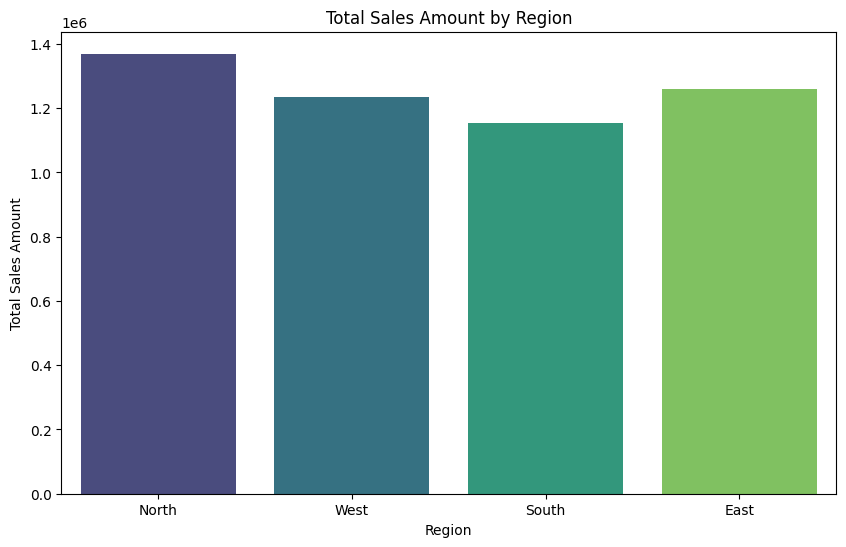

/tmp/ipykernel_662/1237179933.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Product_Category', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='mako')
/tmp/ipykernel_662/1237179933.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='mako')


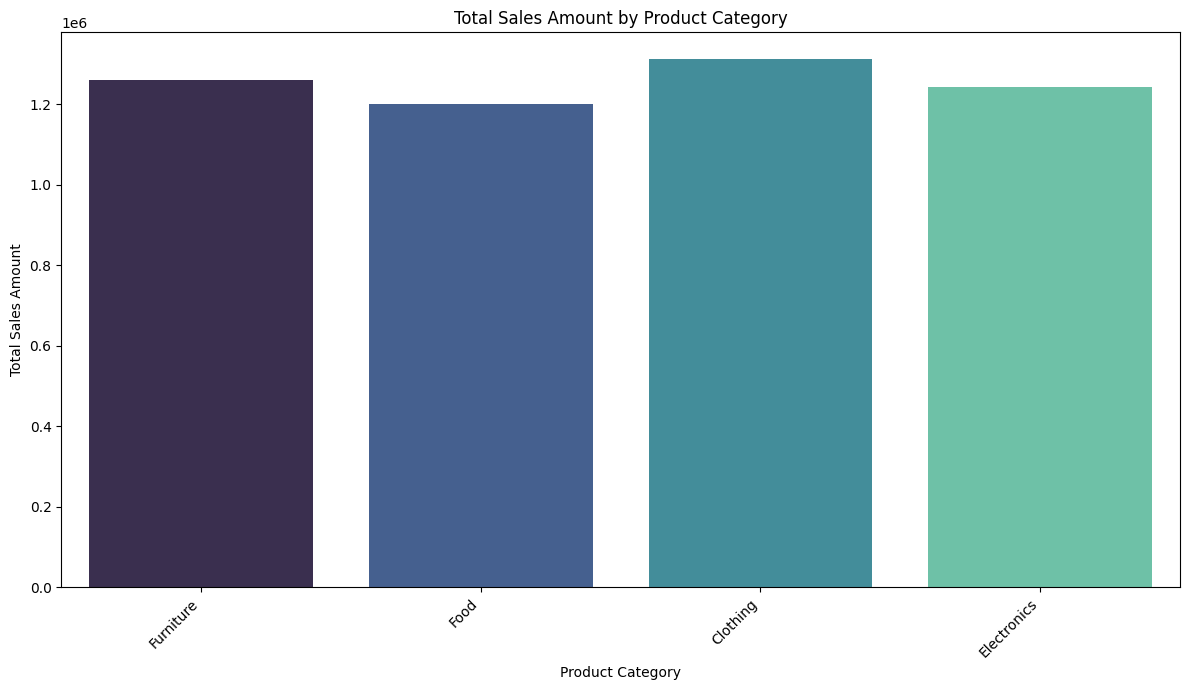

In [13]:
# Sales by Region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='viridis')
plt.title('Total Sales Amount by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales Amount')
plt.show()

# Sales by Product Category
plt.figure(figsize=(12, 7))
sns.barplot(x='Product_Category', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='mako')
plt.title('Total Sales Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 6. Sales by Sales Representative

Let's visualize the total sales amount contributed by each sales representative.

/tmp/ipykernel_662/1483430077.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sales_Rep', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='rocket')
/tmp/ipykernel_662/1483430077.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales_Rep', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='rocket')


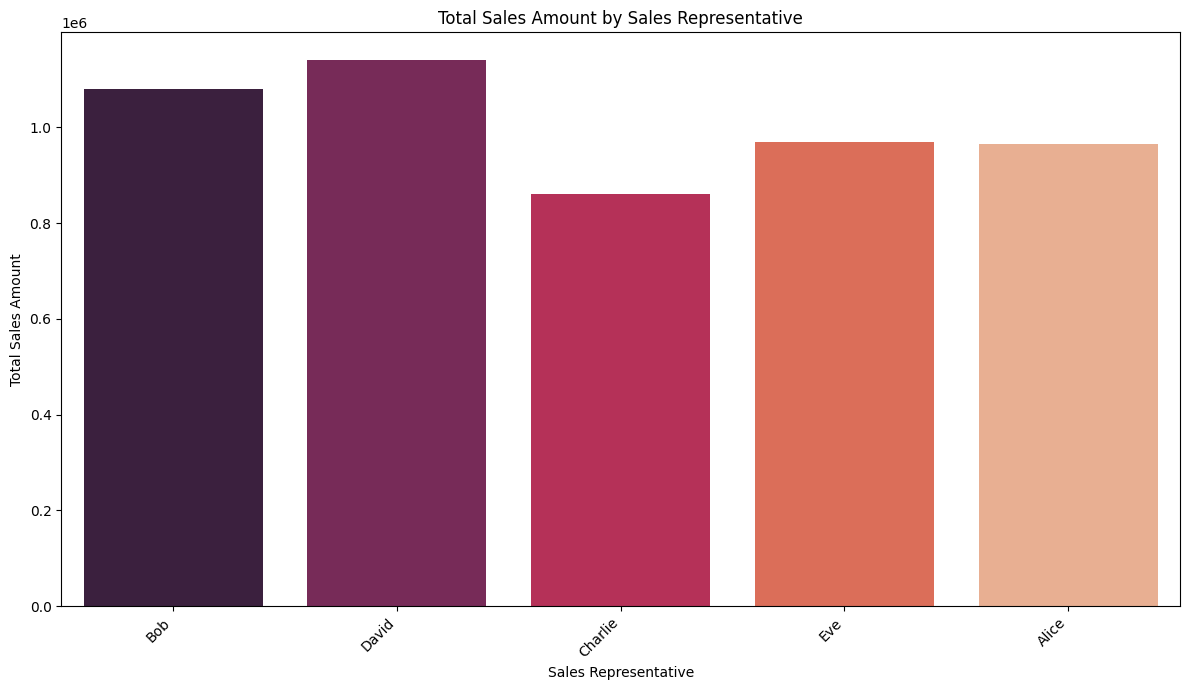

In [14]:
# Sales by Sales Representative
plt.figure(figsize=(12, 7))
sns.barplot(x='Sales_Rep', y='Sales_Amount', data=df, estimator=sum, ci=None, palette='rocket')
plt.title('Total Sales Amount by Sales Representative')
plt.xlabel('Sales Representative')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Business Insights and Summary Tables

Building on the visualizations, let's create specific summary tables to quantify important patterns and trends.

#### 1. Total Sales Amount by Region

This table quantifies the total sales generated by each region, allowing for a clear comparison of regional performance.

In [15]:
regional_sales = df.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False).reset_index()
print("Total Sales Amount by Region:")
display(regional_sales)

Total Sales Amount by Region:


,Region,Sales_Amount
0,North,1369612.51
1,East,1259792.93
2,West,1235608.93
3,South,1154250.86


#### 2. Total Sales Amount by Product Category

This table highlights which product categories are the biggest revenue drivers.

In [16]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False).reset_index()
print("Total Sales Amount by Product Category:")
display(category_sales)

Total Sales Amount by Product Category:


,Product_Category,Sales_Amount
0,Clothing,1313474.36
1,Furniture,1260517.69
2,Electronics,1243499.64
3,Food,1201773.54


#### 3. Total Sales Amount by Sales Representative

This table quantifies the total sales achieved by each sales representative, indicating top performers.

In [17]:
rep_sales = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False).reset_index()
print("Total Sales Amount by Sales Representative:")
display(rep_sales)

Total Sales Amount by Sales Representative:


,Sales_Rep,Sales_Amount
0,David,1141737.36
1,Bob,1080990.63
2,Eve,970183.99
3,Alice,965541.77
4,Charlie,860811.48


#### 4. Average Sales Amount by Customer Type

This insight compares the average transaction value between new and returning customers.

In [18]:
customer_type_avg_sales = df.groupby('Customer_Type')['Sales_Amount'].mean().reset_index()
print("Average Sales Amount by Customer Type:")
display(customer_type_avg_sales)

Average Sales Amount by Customer Type:


,Customer_Type,Sales_Amount
0,New,4972.734722
1,Returning,5066.546230


#### 5. Monthly Sales Trend

To understand the sales trend more granularly, let's aggregate total sales by month.

In [19]:
# Extract month from Sale_Date and aggregate monthly sales
df['Sale_Month'] = df['Sale_Date'].dt.to_period('M')
monthly_sales = df.groupby('Sale_Month')['Sales_Amount'].sum().reset_index()

# Convert Sale_Month back to string for better display if needed, or keep as Period for sorting
monthly_sales['Sale_Month'] = monthly_sales['Sale_Month'].astype(str)

print("Total Sales Amount by Month:")
display(monthly_sales)

Total Sales Amount by Month:


,Sale_Month,Sales_Amount
0,2023-01,476092.36
1,2023-02,368919.36
2,2023-03,402638.77
3,2023-04,438992.61
4,2023-05,389078.76
5,2023-06,418458.34
6,2023-07,374242.88
7,2023-08,443171.28
8,2023-09,367837.60
9,2023-10,460378.78


#### 6. Sales Performance by Sales Channel

This table shows the total sales contribution from 'Retail' versus 'Online' channels.

In [20]:
channel_sales = df.groupby('Sales_Channel')['Sales_Amount'].sum().sort_values(ascending=False).reset_index()
print("Total Sales Amount by Sales Channel:")
display(channel_sales)

Total Sales Amount by Sales Channel:


,Sales_Channel,Sales_Amount
0,Retail,2560431.30
1,Online,2458833.93


### Visualizing Key Insights from the Dataset

Building on the summary tables, let's create visualizations to provide a clearer and more intuitive understanding of the data.

#### 1. Total Sales Amount by Region

This bar chart visualizes the total sales generated by each geographical region, clearly showing their relative contributions.

/tmp/ipykernel_662/2556294137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales_Amount', data=regional_sales, palette='viridis')


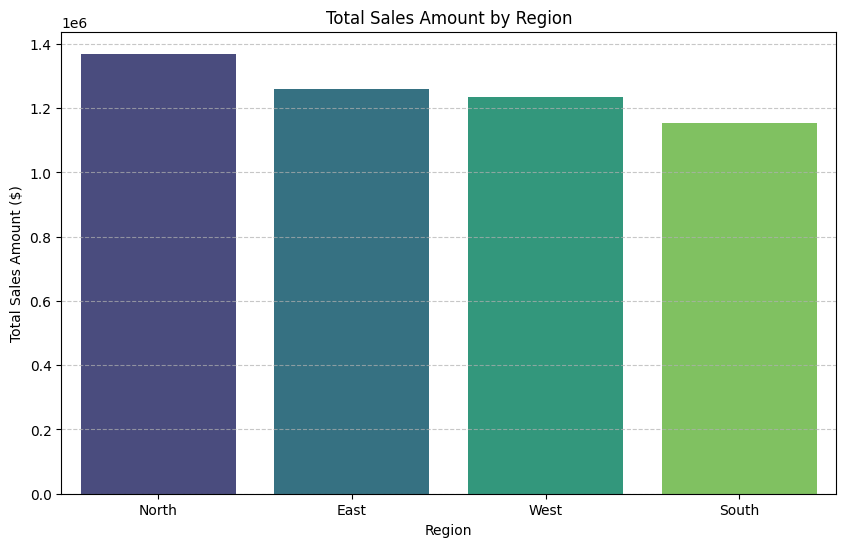

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Sales_Amount', data=regional_sales, palette='viridis')
plt.title('Total Sales Amount by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 2. Total Sales Amount by Product Category

This chart highlights which product categories are the most significant revenue drivers.

/tmp/ipykernel_662/2847094669.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='Sales_Amount', data=category_sales, palette='mako')


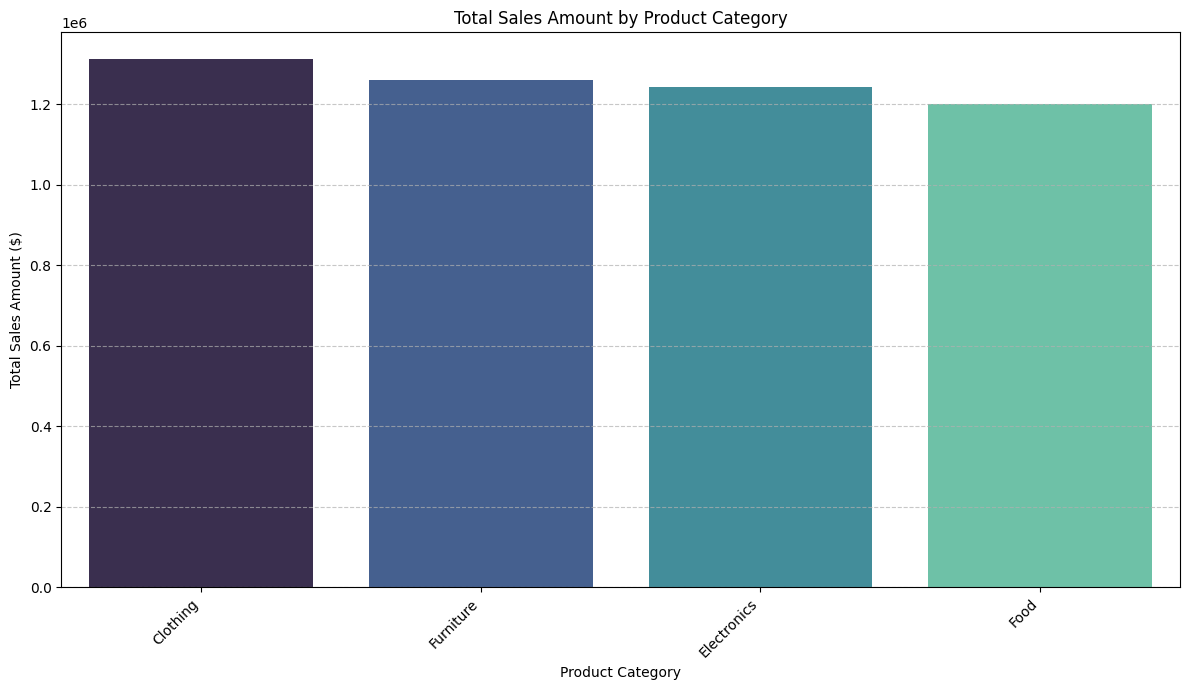

In [23]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Product_Category', y='Sales_Amount', data=category_sales, palette='mako')
plt.title('Total Sales Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 3. Total Sales Amount by Sales Representative

This bar chart illustrates the total sales contribution of each sales representative, allowing us to easily identify top performers.

/tmp/ipykernel_662/2187811595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales_Rep', y='Sales_Amount', data=rep_sales, palette='rocket')


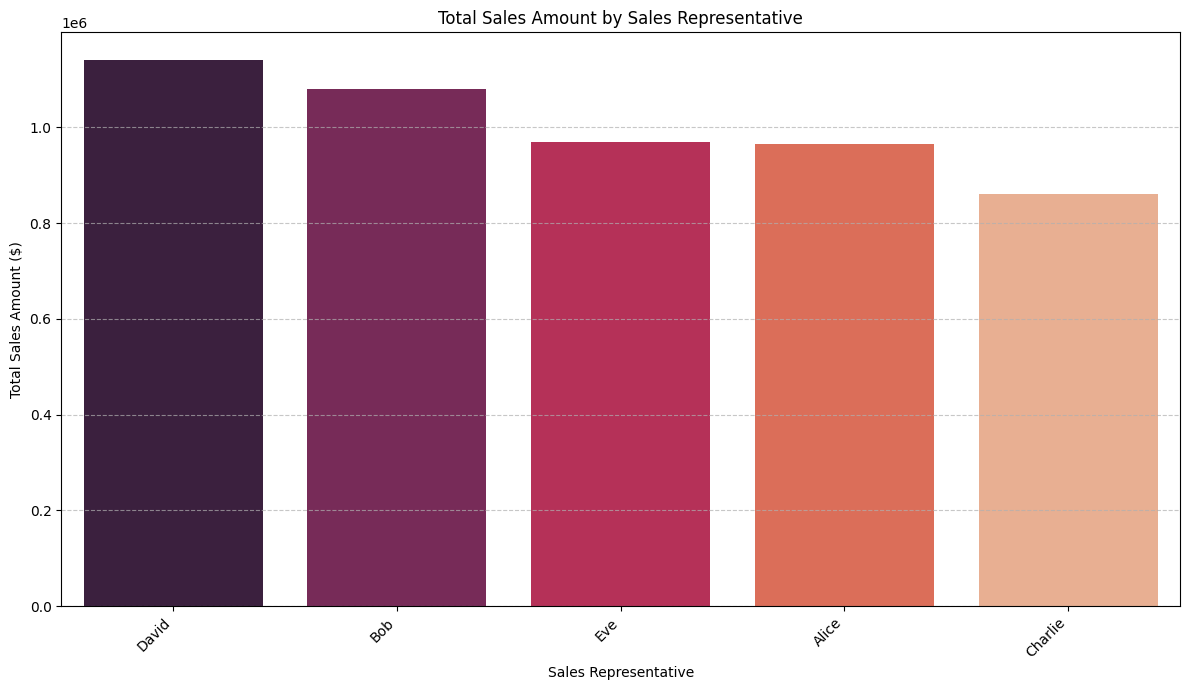

In [24]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Sales_Rep', y='Sales_Amount', data=rep_sales, palette='rocket')
plt.title('Total Sales Amount by Sales Representative')
plt.xlabel('Sales Representative')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 4. Monthly Sales Trend

This line plot visualizes the aggregated sales amount over each month, helping to identify seasonal patterns or general trends throughout the year.

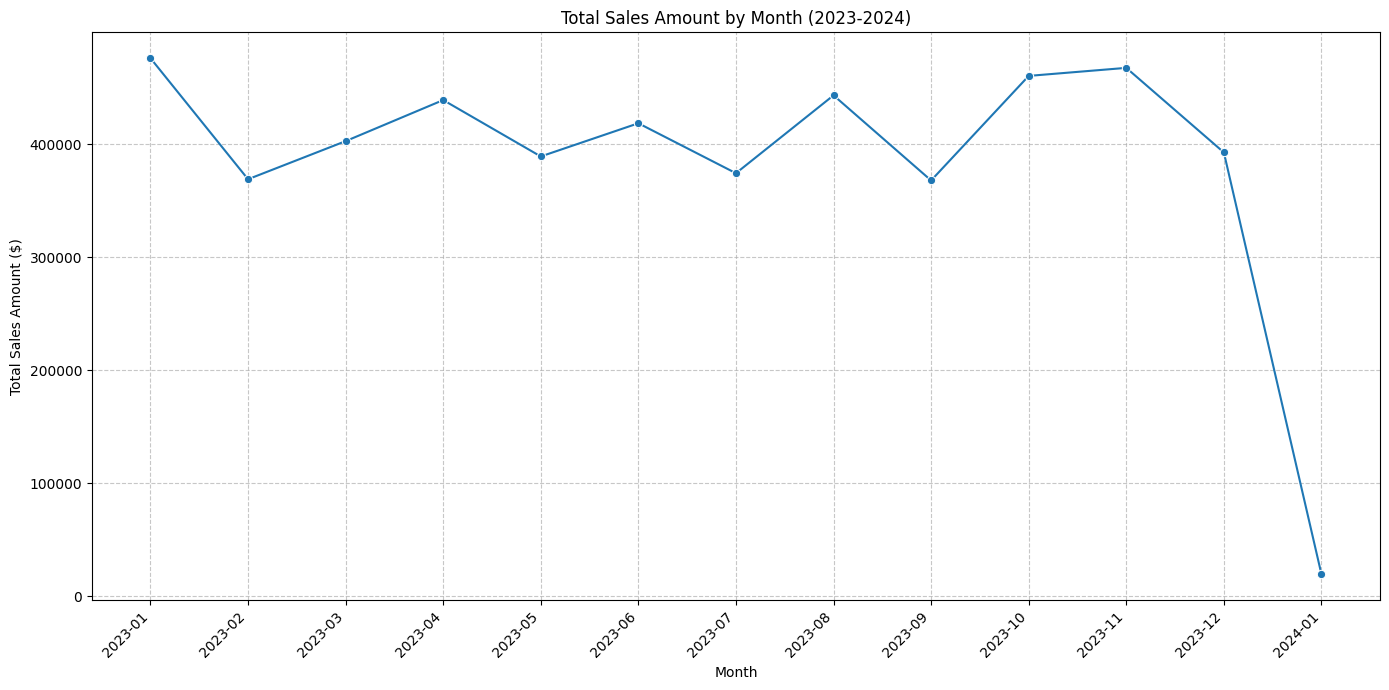

In [25]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Sale_Month', y='Sales_Amount', data=monthly_sales, marker='o')
plt.title('Total Sales Amount by Month (2023-2024)')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 5. Average Sales Amount by Customer Type

This chart compares the average sales amount per transaction between new and returning customers, providing insight into their purchasing behavior.

/tmp/ipykernel_662/778950346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Type', y='Sales_Amount', data=customer_type_avg_sales, palette='pastel')


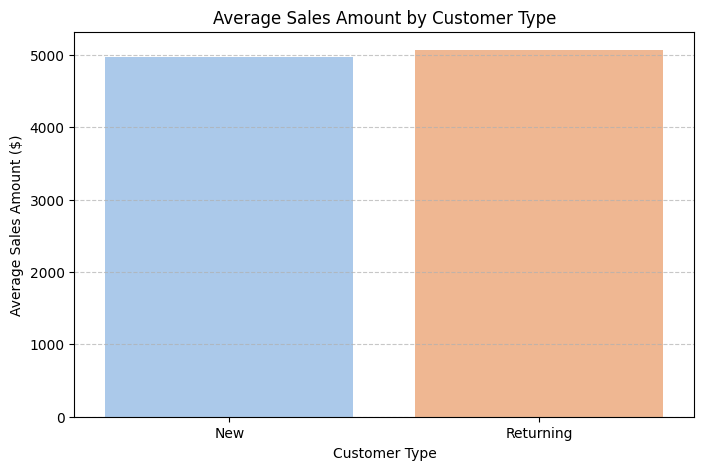

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Customer_Type', y='Sales_Amount', data=customer_type_avg_sales, palette='pastel')
plt.title('Average Sales Amount by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 6. Total Sales Amount by Sales Channel

This visualization shows the total sales generated through 'Retail' versus 'Online' channels, highlighting the relative importance of each.

### Multivariate Analysis

To gain deeper insights, let's explore relationships involving multiple variables. These visualizations will help us understand how different factors interact and influence sales.

#### 1. Sales Amount by Product Category and Region

This visualization will show which product categories are most popular or generate the highest sales in each region, helping to identify regional product preferences.

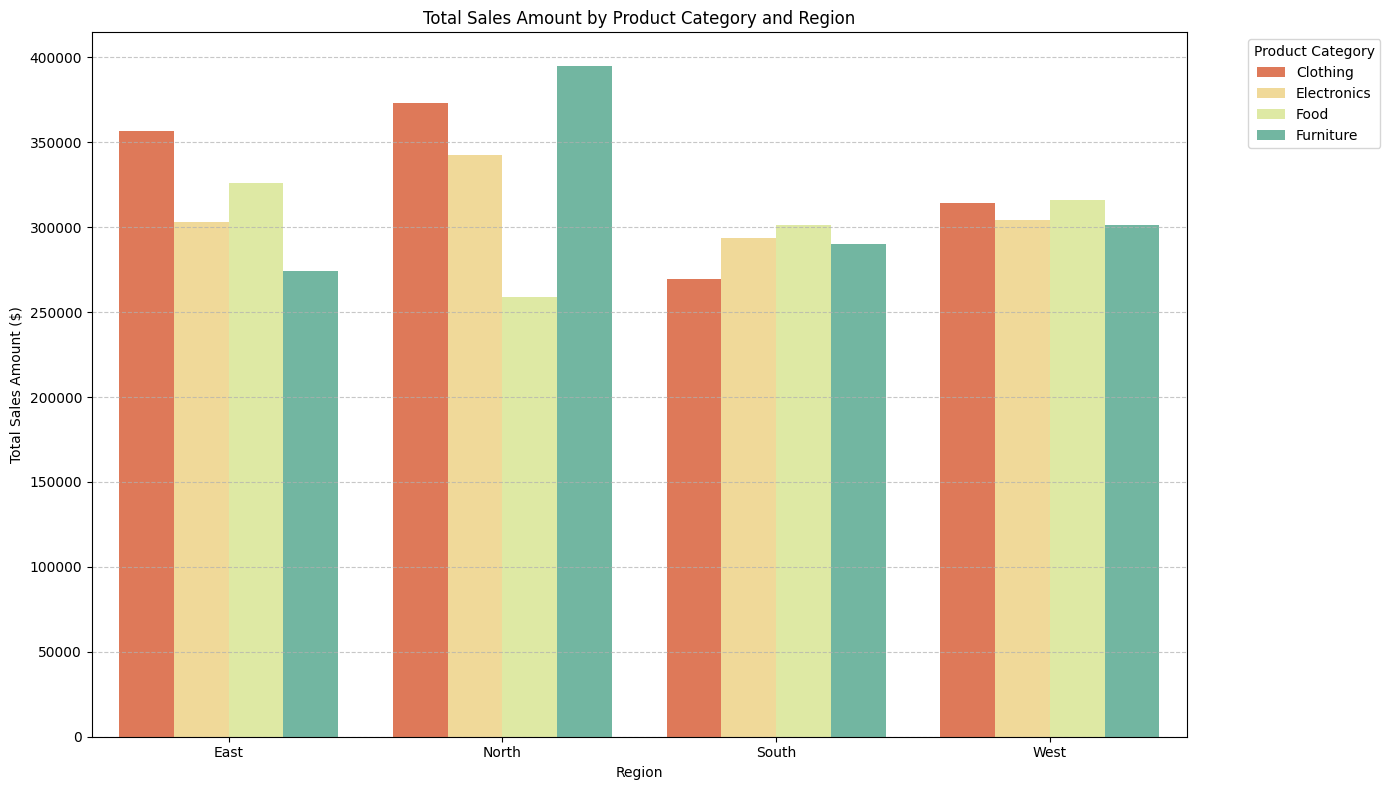

In [28]:
# Group by Region and Product_Category and sum Sales_Amount
sales_by_category_region = df.groupby(['Region', 'Product_Category'])['Sales_Amount'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='Region', y='Sales_Amount', hue='Product_Category', data=sales_by_category_region, palette='Spectral')
plt.title('Total Sales Amount by Product Category and Region')
plt.xlabel('Region')
plt.ylabel('Total Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 2. Sales Amount by Customer Type and Sales Channel

This chart explores whether new and returning customers prefer certain sales channels, which can inform marketing and sales strategies.

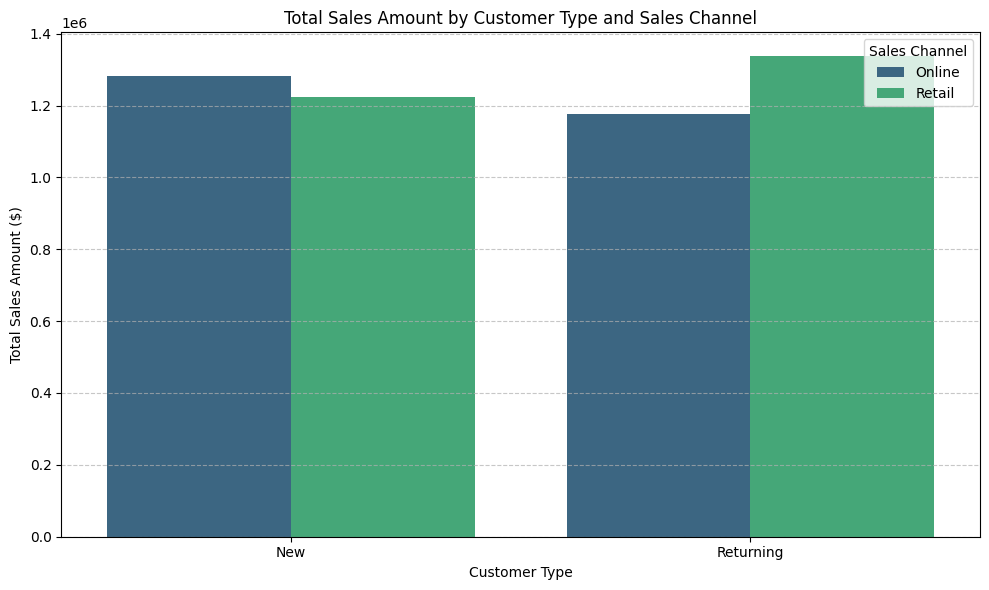

In [29]:
# Group by Customer_Type and Sales_Channel and sum Sales_Amount
sales_by_customer_channel = df.groupby(['Customer_Type', 'Sales_Channel'])['Sales_Amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Customer_Type', y='Sales_Amount', hue='Sales_Channel', data=sales_by_customer_channel, palette='viridis')
plt.title('Total Sales Amount by Customer Type and Sales Channel')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Sales Channel')
plt.tight_layout()
plt.show()

#### 3. Sales Amount by Payment Method and Product Category

This visualization helps understand if there's a correlation between the payment method used and the product category purchased, which could be useful for payment processing and promotions.

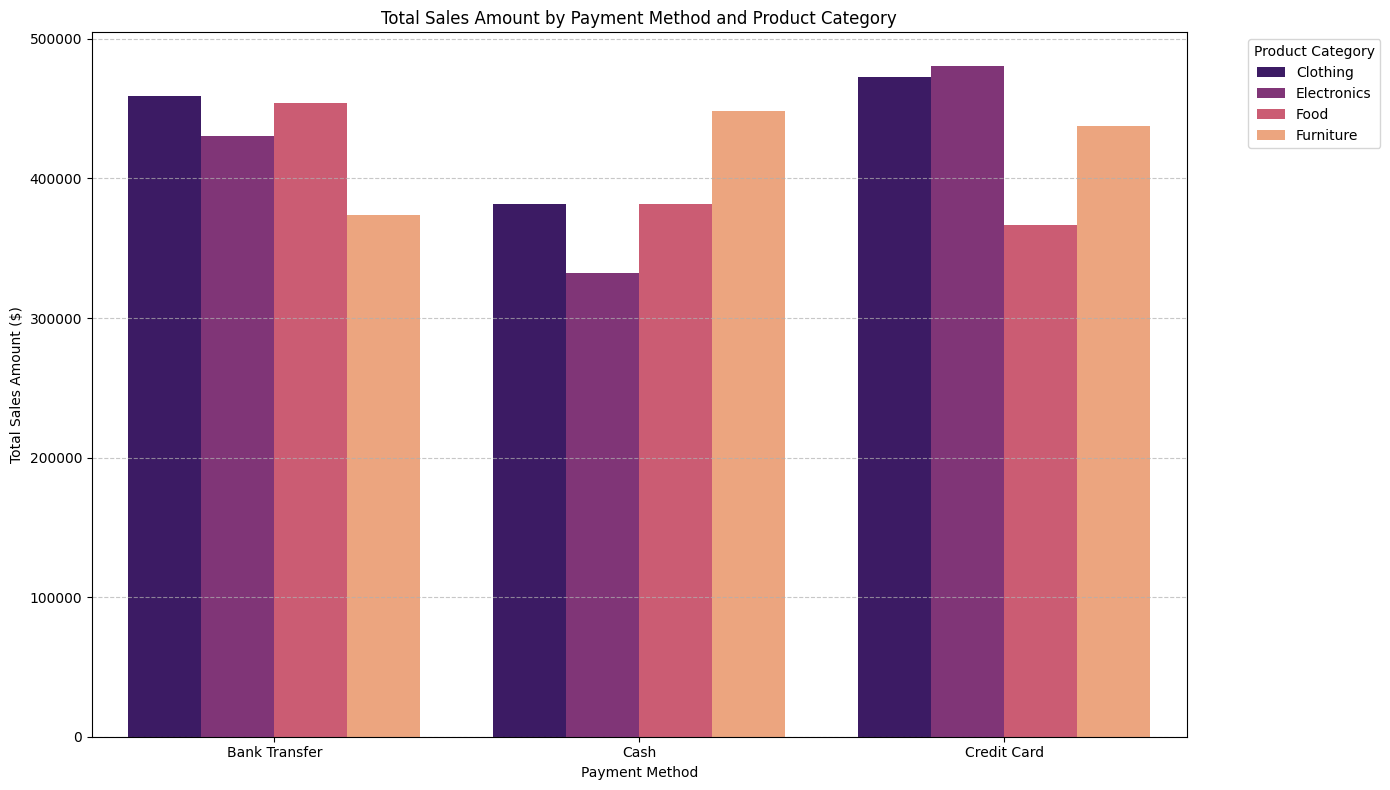

In [30]:
# Group by Payment_Method and Product_Category and sum Sales_Amount
sales_by_payment_category = df.groupby(['Payment_Method', 'Product_Category'])['Sales_Amount'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='Payment_Method', y='Sales_Amount', hue='Product_Category', data=sales_by_payment_category, palette='magma')
plt.title('Total Sales Amount by Payment Method and Product Category')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 4. Correlation Heatmap of Numerical Features

This heatmap visualizes the correlation matrix of numerical columns, helping to identify strong positive or negative relationships between them.

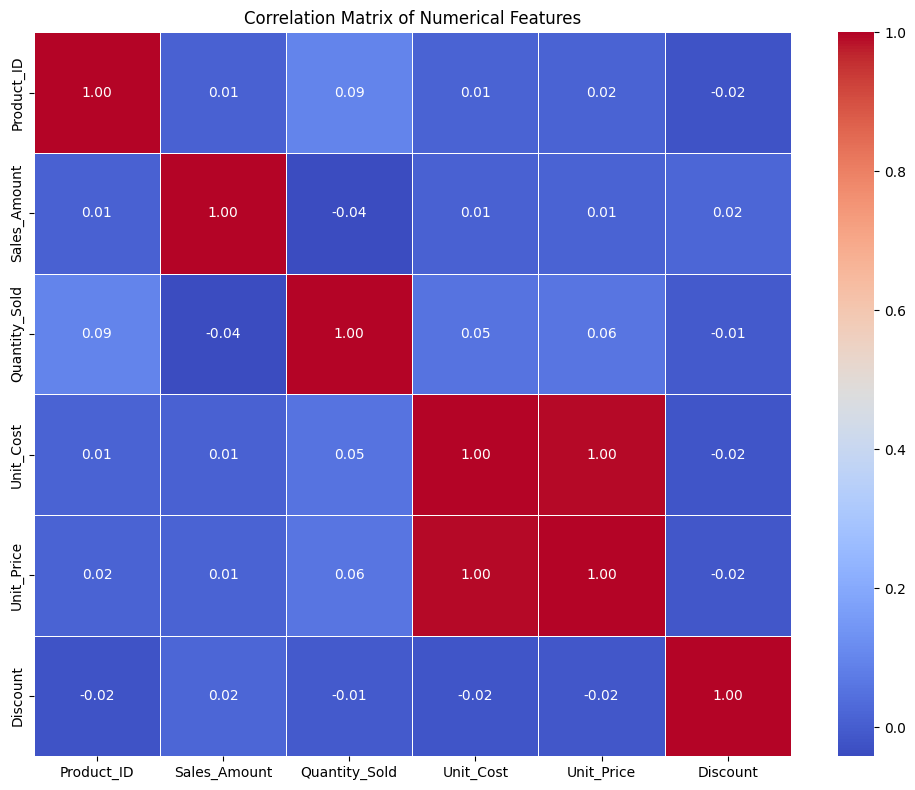

In [31]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

/tmp/ipykernel_662/168335345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales_Channel', y='Sales_Amount', data=channel_sales, palette='dark')


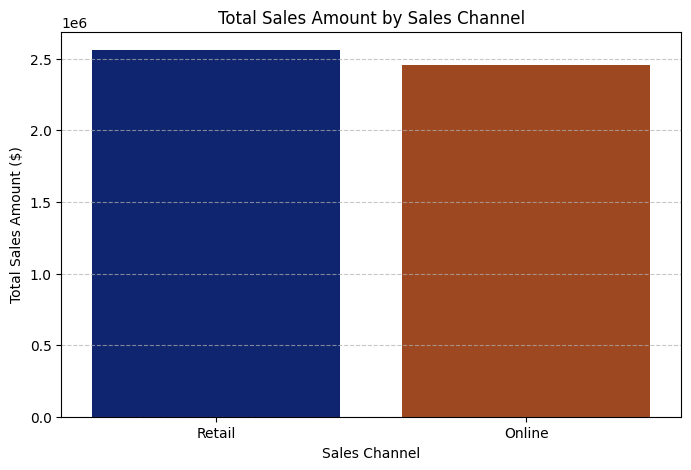

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Sales_Channel', y='Sales_Amount', data=channel_sales, palette='dark')
plt.title('Total Sales Amount by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Final Data Analysis Report

## 1. Dataset Overview

The dataset `sales_data.csv.csv` contains sales transaction records. It has **1000 rows** and **14 columns**. Key columns include:

*   `Product_ID`: Unique identifier for products.
*   `Sale_Date`: Date of the sale.
*   `Sales_Rep`: Sales representative involved in the transaction.
*   `Region`: Geographical region of the sale.
*   `Sales_Amount`: Total sales amount for the transaction.
*   `Quantity_Sold`: Number of units sold.
*   `Product_Category`: Category of the product.
*   `Unit_Cost`, `Unit_Price`: Cost and selling price per unit.
*   `Customer_Type`: Indicates if the customer is 'New' or 'Returning'.
*   `Discount`: Discount applied to the sale.
*   `Payment_Method`: Method of payment (e.g., Credit Card, Bank Transfer, Cash).
*   `Sales_Channel`: Channel through which the sale occurred (e.g., Retail, Online).

The initial data types were a mix of `int64`, `float64`, and `object`. The `Sale_Date` was initially an `object` type.

## 2. Data Cleaning Steps

The following data cleaning steps were performed:

*   **Missing Values Check**: No missing values were found across any columns in the dataset.
*   **Duplicate Rows Check**: No duplicate rows were found in the dataset.
*   **Data Type Conversion**: The `Sale_Date` column was successfully converted from an `object` type to `datetime64[ns]` to enable time-series analysis.

## 3. Exploratory Data Analysis (EDA) Findings

EDA was conducted to understand the data distribution, relationships, and identify patterns.

*   **Descriptive Statistics**: Provided summaries for numerical columns (`Sales_Amount`, `Quantity_Sold`, `Unit_Cost`, `Unit_Price`, `Discount`), showing their central tendencies and spread.
*   **Categorical Feature Analysis**: Value counts revealed the distribution of categories for `Sales_Rep`, `Region`, `Product_Category`, `Customer_Type`, `Payment_Method`, and `Sales_Channel`. For instance, 'David' is the top sales rep, 'North' and 'East' are leading regions, and 'Clothing'/'Furniture' are top product categories.
*   **Sales Amount Distribution**: The histogram of `Sales_Amount` showed a relatively spread distribution, without a strong skew, indicating a variety of transaction sizes.
*   **Sales Over Time**: A line plot of total sales amount over time indicated daily fluctuations and some peak sales periods.


## 4. Key Visualizations and Insights

Several visualizations were created to highlight important patterns and relationships:

### Univariate/Bivariate Visualizations:

1.  **Total Sales Amount by Region**: Bar chart showing **North** and **East** as leading regions in total sales.
2.  **Total Sales Amount by Product Category**: Bar chart indicating **Clothing** and **Furniture** as the highest revenue-generating product categories.
3.  **Total Sales Amount by Sales Representative**: Bar chart identifying **David** as the top-performing sales representative.
4.  **Monthly Sales Trend**: Line plot showing sales fluctuations throughout 2023, with peaks in late spring and fall.
5.  **Average Sales Amount by Customer Type**: Bar chart revealing that **Returning customers** have a slightly higher average sales amount per transaction than 'New' customers.
6.  **Total Sales Amount by Sales Channel**: Bar chart demonstrating that the **Retail** channel slightly surpasses the **Online** channel in total sales.

### Multivariate Visualizations:

1.  **Total Sales Amount by Product Category and Region**: This stacked bar chart showed regional product preferences, with Clothing and Electronics being strong in North and East, and Furniture consistently strong across all regions.
2.  **Total Sales Amount by Customer Type and Sales Channel**: This bar chart indicated that new customers drive more online sales, while returning customers contribute more through retail.
3.  **Total Sales Amount by Payment Method and Product Category**: This visualization suggested that Credit Card is the most dominant payment method across all product categories, especially for Clothing and Electronics.
4.  **Correlation Matrix of Numerical Features**: A heatmap revealed a very strong positive correlation between `Unit_Cost` and `Unit_Price` (0.99). Other numerical features showed very weak correlations with `Sales_Amount`, suggesting that sales amount is influenced more by categorical factors or complex interactions.

## 5. Key Business Insights

Based on the analysis, here are the key business insights:

*   **Regional Performance**: The **North** and **East** regions are the strongest in terms of total sales, indicating potential for growth or focus areas. The **South** region consistently underperforms in sales across product categories.
*   **Product Category Performance**: **Clothing** and **Furniture** are the primary revenue drivers. Focusing on inventory management and promotional strategies for these categories could be beneficial.
*   **Sales Representative Effectiveness**: **David** is a top performer, while **Charlie** consistently has lower sales. This highlights areas for training or performance review for sales representatives.
*   **Customer Behavior**: Returning customers tend to make slightly larger purchases on average. This emphasizes the importance of customer retention strategies. The sales channel analysis indicates that new customers are acquired more effectively online, while retail reinforces loyalty with returning customers.
*   **Sales Trends**: Monthly sales show fluctuations, suggesting potential seasonality or impact from promotional activities. Further investigation into specific periods of high and low sales could inform future planning.
*   **Payment Methods**: Credit Card is the most popular payment method across all product categories. Understanding payment preferences can help optimize transaction processes and promotions.

This analysis provides a foundational understanding of the sales data, identifying key trends, top performers, and areas for potential strategic focus.

# Sales Data Analysis Project

## Project Objective

The primary objective of this project was to perform a comprehensive analysis of sales data to uncover key trends, patterns, and insights that can inform business decisions. This involved data loading, cleaning, exploratory data analysis (EDA), visualization, and multivariate analysis to understand the factors influencing sales performance.

## Tools Used

*   **Python**: The core programming language for data analysis.
*   **Pandas**: For data manipulation and analysis.
*   **Matplotlib**: For creating static, interactive, and animated visualizations.
*   **Seaborn**: A high-level data visualization library based on Matplotlib, used for creating informative and attractive statistical graphics.

## Steps Performed

1.  **Data Loading and Initial Inspection**: Loaded the `sales_data.csv.csv` file into a pandas DataFrame. Inspected its shape, columns, data types, and the first few rows.
2.  **Data Cleaning**: Checked for and confirmed the absence of missing values and duplicate rows. Converted the `Sale_Date` column to datetime objects for time-series analysis.
3.  **Exploratory Data Analysis (EDA)**: Conducted descriptive statistics for numerical columns and value counts for categorical features. Visualized the distribution of `Sales_Amount` and the trend of `Sales_Amount` over time.
4.  **Key Business Insights and Summary Tables**: Generated quantitative summary tables and derived initial insights regarding regional sales, product category performance, sales representative effectiveness, customer type average sales, monthly sales trends, and sales channel performance.
5.  **Visualizations**: Created a series of bar charts and line plots to visually represent the key findings from the EDA, including total sales by region, product category, sales representative, monthly trends, average sales by customer type, and total sales by sales channel.
6.  **Multivariate Analysis**: Explored relationships between multiple variables through visualizations such as:
    *   Total Sales Amount by Product Category and Region.
    *   Total Sales Amount by Customer Type and Sales Channel.
    *   Total Sales Amount by Payment Method and Product Category.
    *   Correlation Heatmap of Numerical Features.
7.  **Final Summary Report**: Compiled a comprehensive report detailing the project overview, cleaning steps, EDA findings, key visualizations, and a synthesis of all business insights.

## Key Insights

*   **Regional Performance**: The **North** and **East** regions are the top performers in terms of total sales, with the **South** region consistently lagging.
*   **Product Category Dominance**: **Clothing** and **Furniture** emerged as the primary revenue drivers, indicating strong market demand for these product categories.
*   **Sales Representative Effectiveness**: **David** was identified as the highest-performing sales representative, while **Charlie** had the lowest total sales.
*   **Customer Behavior**: **Returning customers** show a slightly higher average sales amount per transaction, highlighting the value of customer retention. New customers are more engaged through online channels, while retail is strong for returning customers.
*   **Sales Trends**: Sales data exhibited fluctuations with notable peaks and dips throughout the year, suggesting potential seasonality or impact from promotional activities. January 2024 data appears incomplete.
*   **Sales Channel Impact**: The **Retail** channel slightly outperformed the **Online** channel in total sales, although both contribute significantly.
*   **Payment Preferences**: **Credit Card** is the most widely used payment method across all product categories, especially for Clothing and Electronics.
*   **Numerical Feature Relationships**: A very strong positive correlation was observed between `Unit_Cost` and `Unit_Price`. `Sales_Amount` showed weak linear correlations with other numerical features, suggesting its drivers are more complex or linked to categorical variables.

## 6. Saving Cleaned Data and Organizing Project Files

### Saving the Cleaned Dataset

I will now save the cleaned `df` DataFrame to a new CSV file named `cleaned_sales_data.csv`.

In [32]:
# Save the cleaned DataFrame to a new CSV file
df.to_csv('cleaned_sales_data.csv', index=False)
print("Cleaned data saved successfully to 'cleaned_sales_data.csv'")

Cleaned data saved successfully to 'cleaned_sales_data.csv'
